# 12. TWOSIDES DDI (via PyTDC) EDA (T0-3)

**데이터 출처**: Therapeutics Data Commons (TDC) — `tdc.multi_pred.DDI`  
**파이프라인 역할**: Stage 2 DDI 검색 베이스라인 / 국제 데이터 매핑 가능성 평가

## EDA 체크리스트
- [ ] 약물 수, DDI pair 수
- [ ] 한국 낱알식별 성분명과 매핑되는 약물 수 → DDI 재현율 상한선
- [ ] pair 수 분포 (long-tail; FAISS 크기 추정)
- [ ] 대칭성 확인 (A→B vs B→A)
- [ ] 산출물: `data/interim/twosides_clean.parquet` + `twosides_summary.json`

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("../../").resolve()
INTERIM = ROOT / "data" / "interim"

In [2]:
# TWOSIDES 데이터 로드
from tdc.multi_pred import DDI

data = DDI(name="TWOSIDES", path=str(ROOT / "data" / "raw" / "tdc"))
split = data.get_split()

# train/valid/test 합산
df = pd.concat([split["train"], split["valid"], split["test"]], ignore_index=True)
print(f"shape: {df.shape}")
print(df.dtypes)
df.head(3)

Found local copy...
Loading...
Done!


shape: (4649441, 5)
Drug1_ID    object
Drug1       object
Drug2_ID    object
Drug2       object
Y            int64
dtype: object


,Drug1_ID,Drug1,Drug2_ID,Drug2,Y
0,CID000002173,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=CC=C3)N)C(=O...,CID000003345,CCC(=O)N(C1CCN(CC1)CCC2=CC=CC=C2)C3=CC=CC=C3,767
1,CID000002173,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=CC=C3)N)C(=O...,CID000003345,CCC(=O)N(C1CCN(CC1)CCC2=CC=CC=C2)C3=CC=CC=C3,25
2,CID000002173,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=CC=C3)N)C(=O...,CID000003345,CCC(=O)N(C1CCN(CC1)CCC2=CC=CC=C2)C3=CC=CC=C3,85


In [9]:
# 컬럼명 확인 후 drug1/drug2 식별
print(df.columns.tolist())

['Drug1_ID', 'Drug1', 'Drug2_ID', 'Drug2', 'Y']


In [10]:
# 약물 수 / pair 수
drug_cols = [c for c in df.columns if "drug" in c.lower() or "smiles" in c.lower()]
id_col1, id_col2 = drug_cols[0], drug_cols[1] if len(drug_cols) >= 2 else (drug_cols[0], drug_cols[0])

all_drugs = pd.concat([df[id_col1], df[id_col2]]).unique()
print(f"유일 약물 수: {len(all_drugs):,}")
print(f"DDI pair 수: {len(df):,}")

유일 약물 수: 1,232
DDI pair 수: 4,649,441


count     1232.000000
mean      7547.793831
std      11291.924275
min          6.000000
25%        387.750000
50%       2540.500000
75%      10231.000000
max      68416.000000
Name: count, dtype: float64


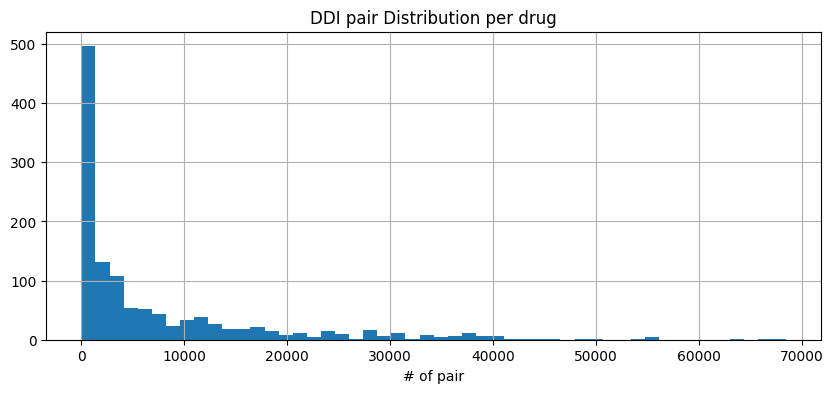

In [11]:
# 약물별 pair 수 분포
pair_counts = pd.concat([
    df[id_col1].value_counts(),
    df[id_col2].value_counts()
]).groupby(level=0).sum()

print(pair_counts.describe())
pair_counts.hist(bins=50, figsize=(10, 4))
plt.title("DDI pair Distribution per drug")
plt.xlabel("# of pair")
plt.show()

In [12]:
# 대칭성 확인
forward = set(zip(df[id_col1], df[id_col2]))
backward = set(zip(df[id_col2], df[id_col1]))
symmetric = forward & backward
print(f"대칭 pair: {len(symmetric):,} / 전체: {len(forward):,} ({len(symmetric)/len(forward):.1%})")

대칭 pair: 0 / 전체: 616 (0.0%)


In [7]:
# 한국 낱알식별 → TWOSIDES 매핑 (korean_cid_crosswalk 활용)
crosswalk_path = INTERIM / "korean_cid_crosswalk.parquet"
if crosswalk_path.exists():
    df_cross = pd.read_parquet(crosswalk_path)
    twosides_ids = set(pd.concat([df["Drug1_ID"], df["Drug2_ID"]]).unique())

    matched = df_cross["TWOSIDES_ID"].isin(twosides_ids)
    n_matched = matched.sum()
    n_total = len(df_cross)

    print(f"한국 품목 → TWOSIDES 매핑 커버리지: {n_matched/n_total:.1%} ({n_matched:,}/{n_total:,})")
    print(f"TWOSIDES 수록 약물 중 한국 품목 포함: {df_cross.loc[matched, 'TWOSIDES_ID'].nunique():,}종")
    display(df_cross[matched][["ITEM_SEQ", "ITEM_NAME", "INGR_KR", "TWOSIDES_ID"]].head(5))
else:
    print("crosswalk 없음 — 01_korean_id_ontology 먼저 실행")
    n_matched, n_total = 0, 0

한국 품목 → TWOSIDES 매핑 커버리지: 5.8% (1,484/25,518)
TWOSIDES 수록 약물 중 한국 품목 포함: 70종


,ITEM_SEQ,ITEM_NAME,INGR_KR,TWOSIDES_ID
7,200809883,아푸르탄정150밀리그램(이르베사르탄),이르베사르탄,CID000003749
103,200101951,한신타미놀캅셀(아세트아미노펜),아세트아미노펜,CID000001983
280,200905264,린피스정(아스피린),아스피린,CID000002244
292,200905198,넥스핀정(아스피린),아스피린,CID000002244
308,201001683,텔미스정40mg(텔미사르탄),텔미사르탄,CID000065999


In [13]:
# 산출물 저장
df.to_parquet(INTERIM / "twosides_clean.parquet", index=False)

summary = {
    "total_pairs": len(df),
    "unique_drugs": int(len(all_drugs)),
    "columns": df.columns.tolist(),
    "symmetric_pair_rate": float(len(symmetric) / len(forward)),
    "korean_item_matched": int(n_matched),
    "korean_item_total": int(n_total),
    "korean_coverage": round(n_matched / n_total, 4) if n_total > 0 else 0.0,
}
with open(INTERIM / "twosides_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("저장 완료")
print(json.dumps(summary, indent=2))

저장 완료
{
  "total_pairs": 4649441,
  "unique_drugs": 1232,
  "columns": [
    "Drug1_ID",
    "Drug1",
    "Drug2_ID",
    "Drug2",
    "Y"
  ],
  "symmetric_pair_rate": 0.0,
  "korean_item_matched": 1484,
  "korean_item_total": 25518,
  "korean_coverage": 0.0582
}
